# Engineering simulator: four coordinated foundations

This executed example demonstrates isolated design cases, typed calculation provenance, a coupled relief/blowdown/flare envelope, and dynamic ESD response verification. Results remain review-required engineering evidence.

In [1]:
import os, sys
from pathlib import Path
ROOT = Path(os.environ.get('NEQSIM_PROJECT_ROOT', Path.cwd())).resolve()
while not (ROOT / 'pom.xml').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'devtools'))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=ROOT, recompile=not (ROOT / 'target/classes').exists(), verbose=False))
import jpype
JClass, JProxy = ns.JClass, jpype.JProxy
import pandas as pd
import matplotlib.pyplot as plt
print('Loaded NeqSim engineering simulator from', ROOT)

All NeqSim classes imported OK
Loaded NeqSim engineering simulator from /workspace/scratch/0f75633c511c/neqsim


In [2]:
SystemSrkEos = JClass('neqsim.thermo.system.SystemSrkEos')
ProcessSystem = JClass('neqsim.process.processmodel.ProcessSystem')
Stream = JClass('neqsim.process.equipment.stream.Stream')
ESDValve = JClass('neqsim.process.equipment.valve.ESDValve')
EngineeringDesignCase = JClass('neqsim.process.engineering.designcase.EngineeringDesignCase')
CaseType = JClass('neqsim.process.engineering.designcase.EngineeringDesignCase$Type')
Configurator = JClass('neqsim.process.engineering.designcase.EngineeringDesignCase$Configurator')
CaseInput = JClass('neqsim.process.engineering.designcase.EngineeringDesignCase$Input')
EngineeringCaseSet = JClass('neqsim.process.engineering.designcase.EngineeringCaseSet')
EngineeringMetric = JClass('neqsim.process.engineering.designcase.EngineeringMetric')
EngineeringCaseRunner = JClass('neqsim.process.engineering.designcase.EngineeringCaseRunner')
EngineeringCaseRunOptions = JClass('neqsim.process.engineering.designcase.EngineeringCaseRunOptions')
fluid = SystemSrkEos(303.15, 50.0)
fluid.addComponent('methane', 0.95); fluid.addComponent('ethane', 0.05); fluid.setMixingRule('classic')
feed = Stream('FEED-100', fluid); feed.setFlowRate(12000.0, 'kg/hr')
esdv = ESDValve('ESDV-100', feed); esdv.setCv(500.0); esdv.setStrokeTime(4.0); esdv.energize()
process = ProcessSystem(); process.setName('Engineering simulator example'); process.add(feed); process.add(esdv); process.run()
def pressure_case(case_id, pressure, priority):
    proxy = JProxy(Configurator, dict(configure=lambda p: p.getUnit('FEED-100').setPressure(pressure, 'bara')))
    return (EngineeringDesignCase(case_id, case_id, CaseType.CUSTOM, proxy).setPriority(priority)
            .addInput(CaseInput('feedPressure', pressure, 'bara', 'DESIGN-BASIS-A')))
case_set = (EngineeringCaseSet('feed-pressure-envelope')
            .addCase(pressure_case('NORMAL', 50.0, 10)).addCase(pressure_case('MAXIMUM', 80.0, 20))
            .addMetric(EngineeringMetric.equipmentPressure('FEED-100')))
case_report = EngineeringCaseRunner.run(process, case_set, EngineeringCaseRunOptions.builder().parallelism(2).build())
case_rows = []
for item in case_report.getEnvelope().getCaseResults():
    case_rows.append({'Case': str(item.getDesignCase().getId()), 'Status': str(item.getStatus()),
                      'Pressure (bara)': float(item.getValues().get('FEED-100.pressure'))})
display(pd.DataFrame(case_rows))
print('Deterministic result fingerprint:', case_report.getResultFingerprint())

Deterministic result fingerprint: 9ad56c5e7068651d0319f31367fe8a25a4aa7645a6028530003797df1b6ceb6e


,Case,Status,Pressure (bara)
0,NORMAL,CALCULATED,50.0
1,MAXIMUM,CALCULATED,80.0


In [3]:
CalculationContext = JClass('neqsim.process.engineering.calculation.EngineeringCalculationContext')
CalculationReadiness = JClass('neqsim.process.engineering.calculation.CalculationReadiness')
CalculationResult = JClass('neqsim.process.engineering.calculation.EngineeringCalculationResult')
CalculationStatus = JClass('neqsim.process.engineering.calculation.EngineeringCalculationResult$Status')
Uncertainty = JClass('neqsim.process.engineering.calculation.EngineeringCalculationResult$Uncertainty')
context = (CalculationContext.builder().designCaseId('MAXIMUM')
           .simulationFingerprint(case_report.getResultFingerprint()).addEvidenceReference('SIM-REV-A')
           .addStandardReference('API 521 project interpretation').build())
readiness = CalculationReadiness.builder().addWarning('CHECK', 'Independent check outstanding', 'Complete discipline check').build()
typed = (CalculationResult.builder('example-duty', 'demonstration method', '1.0').context(context).readiness(readiness)
         .status(CalculationStatus.CALCULATED_REVIEW_REQUIRED).value(12.5).input('caseCount', 2)
         .uncertainty(Uncertainty(11.0, 12.5, 15.0, 'MW', 'case sensitivity')).build())
display(pd.DataFrame([{'Calculation': str(typed.getCalculationId()), 'Status': str(typed.getStatus()),
                       'Value': float(typed.getValue()), 'Approval required': True}]))

,Calculation,Status,Value,Approval required
0,example-duty,CALCULATED_REVIEW_REQUIRED,12.5,True


In [4]:
ProtectedItem = JClass('neqsim.process.safety.overpressure.ProtectedItem')
BlockedOutletRelief = JClass('neqsim.process.safety.overpressure.BlockedOutletRelief')
OverpressureStudy = JClass('neqsim.process.safety.overpressure.OverpressureProtectionStudy')
BlowdownSource = JClass('neqsim.process.safety.depressurization.DynamicBlowdownFlareStudyDataSource$BlowdownSource')
DynamicData = JClass('neqsim.process.safety.depressurization.DynamicBlowdownFlareStudyDataSource')
DynamicRunner = JClass('neqsim.process.safety.depressurization.DynamicBlowdownFlareStudyRunner')
CoupledInput = JClass('neqsim.process.safety.depressurization.CoupledReliefBlowdownFlareInput')
CoupledCalculation = JClass('neqsim.process.safety.depressurization.CoupledReliefBlowdownFlareCalculation')
relief_scenario = (BlockedOutletRelief().setName('Blocked outlet').setInflowRateKgPerS(2.0)
                   .setReliefPressureBara(75.0).setReliefTemperatureC(30.0).setFluid(fluid).calculate())
protected = ProtectedItem('V-100', 80.0).setReliefSetPressureBara(75.0).setBackPressureBara(1.5)
relief_study = OverpressureStudy(protected).addScenario(relief_scenario)
source = (BlowdownSource.builder('V-100', fluid).equipmentTag('V-100').vesselVolumeM3(2.0)
          .orificeDiameterM(0.012).dischargeCoefficient(0.72).backPressureBara(1.5).stopPressureBara(1.5)
          .api521FireCase(8.0, True, True).psvBasis(75.0, 0.21, False, False).build())
dynamic_data = (DynamicData.builder('dynamic-100').addSource(source).flareHeader(0.30, 1.5, 288.15, 0.020, 1.30)
                .flareGeometry(0.5, 35.0, 0.20).flareDesignCapacity(5e8, 500.0, 30000.0).build())
coupled_input = (CoupledInput.builder('coupled-100').addReliefStudy(relief_study, 'FIRE-ZONE-1')
                 .dynamicStudy(dynamic_data).scenarioSelectionReviewed(True).addEvidenceReference('HAZOP-100-A').build())
coupled_calc = CoupledCalculation(DynamicRunner.builder().timeStepSeconds(5.0).maxTimeSeconds(60.0).build())
coupled = coupled_calc.calculate(coupled_input, context)
coupled_value = coupled.getValue()
display(pd.DataFrame([{'Governing load (kg/s)': float(coupled_value.getGoverningMassFlowKgPerS()),
                       'Basis': str(coupled_value.getGoverningBasis()),
                       'Capacity acceptable': bool(coupled_value.isCapacityAcceptable()),
                       'Status': str(coupled.getStatus())}]))

,Governing load (kg/s),Basis,Capacity acceptable,Status
0,2.0,STEADY_RELIEF_CONCURRENCY_GROUP,True,CALCULATED


Dynamic scenario passed: True first safe state (s): 4.0


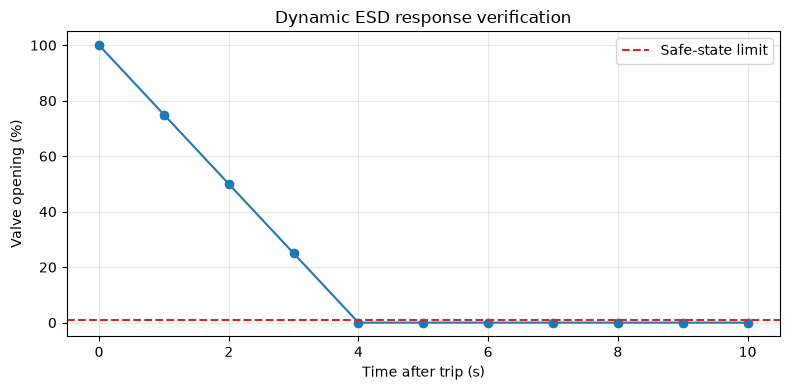

In [5]:
DynamicScenario = JClass('neqsim.process.safety.scenario.DynamicSafetyScenario')
Manipulator = JClass('neqsim.process.safety.scenario.DynamicSafetyScenario$ProcessManipulator')
LogicFactory = JClass('neqsim.process.safety.scenario.DynamicSafetyScenario$LogicFactory')
Criterion = JClass('neqsim.process.safety.scenario.DynamicScenarioCriterion')
Extractor = JClass('neqsim.process.safety.scenario.DynamicScenarioCriterion$Extractor')
ScenarioRunner = JClass('neqsim.process.safety.scenario.DynamicSafetyScenarioRunner')
ESDLogic = JClass('neqsim.process.logic.esd.ESDLogic')
TripValveAction = JClass('neqsim.process.logic.action.TripValveAction')
event = JProxy(Manipulator, dict(apply=lambda p: p.getUnit('ESDV-100').setPercentValveOpening(100.0)))
def build_logic(p):
    logic = ESDLogic('ESD-100')
    logic.addAction(TripValveAction(p.getUnit('ESDV-100')), 0.0)
    return logic
logic_factory = JProxy(LogicFactory, dict(create=build_logic))
opening = JProxy(Extractor, dict(extract=lambda p: p.getUnit('ESDV-100').getPercentValveOpening()))
criterion = Criterion.builder('valve-closed', 'ESD valve closed', '%', opening).acceptanceRange(None, 1.0).deadlineSeconds(6.0).build()
scenario = (DynamicScenario.builder('ESD-100-TEST', 'Trip and close ESD valve').durationSeconds(10.0)
            .timeStepSeconds(1.0).triggerTimeSeconds(0.0).initiatingEvent(event).addLogic(logic_factory)
            .addCriterion(criterion).addEvidenceReference('SRS-100-A').build())
dynamic_result = ScenarioRunner.run(process, scenario)
criterion_map = dynamic_result.toMap().get('criteria').get('valve-closed')
times = list(criterion_map.get('timeSeconds')); values = list(criterion_map.get('values'))
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(times, values, marker='o'); ax.axhline(1.0, color='tab:red', linestyle='--', label='Safe-state limit')
ax.set(xlabel='Time after trip (s)', ylabel='Valve opening (%)', title='Dynamic ESD response verification')
ax.grid(alpha=0.3); ax.legend(); fig.tight_layout(); plt.show()
print('Dynamic scenario passed:', bool(dynamic_result.isPassed()),
      'first safe state (s):', criterion_map.get('firstSatisfiedSeconds'))

The plotted closure is a verification of this supplied dynamic model and criterion. It is not SIL determination, certified SIS verification, or approval of the final trip action.